# ZipBench on SWE-bench Verified (agentic)

This notebook runs the full ZipBench compression pipeline on **SWE-bench Verified** (500 items), an agentic benchmark whose records carry explicit per-instance correctness fields — no answer parsing needed. We use 6 real train models plus 181 held-out test models spanning the public SWE-bench Verified leaderboard.

Pipeline: inspect records → synthesize 6 voting-ensemble models → aggregate to train/test pkl → train a multidimensional 2PL IRT model → compress to weighted anchor subsets (ratios 0.5 and 0.75) → evaluate against the full benchmark.

## 1. Inspect the raw records

Records live in `model/<dataset>.json` layout. Each JSON holds the model's overall accuracy plus a `details` dict with one entry per SWE-bench instance and a binary correctness flag (read priority: `voted_correctness` > `any_correct` > `is_correct`).

In [1]:
import json, glob, os

DATA = "../data/swe_bench_verified"
train_records = sorted(glob.glob(f"{DATA}/train/*/swe_bench_verified.json"))
test_records = sorted(glob.glob(f"{DATA}/testset/*/swe_bench_verified.json"))
print(f"train records: {len(train_records)}, test records: {len(test_records)}")

rec = json.load(open(train_records[0]))
print("\ntop-level keys:", list(rec.keys()))
print({k: rec[k] for k in ("is_correct", "accuracy", "total", "correct")})
first_id = next(iter(rec["details"]))
print(f"details[{first_id!r}] =", rec["details"][first_id])
print("n details:", len(rec["details"]))

train records: 6, test records: 181

top-level keys: ['is_correct', 'accuracy', 'total', 'correct', 'details']
{'is_correct': 0.21, 'accuracy': 21.0, 'total': 500, 'correct': 105}
details['astropy__astropy-12907'] = {'id': 0, 'instance_id': 'astropy__astropy-12907', 'is_correct': 1, 'any_correct': 1}
n details: 500


In [2]:
# Train models with accuracies; the 181-model test list is long, so just show a few.
for p in train_records:
    print(f"{json.load(open(p))['accuracy']:5.1f}%  {os.path.basename(os.path.dirname(p))}")
print(f"\n{len(test_records)} test models, e.g.:")
for p in test_records[:3] + test_records[-2:]:
    print("  ", os.path.basename(os.path.dirname(p)))

 21.0%  official__bash-only.20250720_mini-v0.0.0-Llama-4-Maverick-17B-Instruct
 56.4%  official__bash-only.20251209_mini-v1.17.2_devstral-small-2512
 33.6%  official__verified.20240620_sweagent_claude3.5sonnet
 44.2%  official__verified.20250118_codeshellagent_gemini_2.0_flash_experimental
 78.8%  official__verified.20250928_trae_doubao_seed_code
 68.2%  official__verified.20250930_zai_glm4-6

181 test models, e.g.:
   dashscope__qwen3-next-80b-a3b-thinking.qwen3-next-80b-a3b-thinking
   dashscope__qwen3.5-27b.qwen-3.5-27b
   dashscope__qwen3.5-flash.verified_qwen3.5-flash
   openrouter__z-ai__glm-4.7-flash.glm_4.7_flash copy
   openrouter__z-ai__glm-4.7-flash.glm_4.7_flash


## 2. Synthesize training models

6 real models are too few for stable IRT fitting, so we synthesize 6 extra records by majority-vote ensembles (k ≥ 2 real models), one per uniform accuracy bin. `--strict-bins` fails loudly if a bin cannot be filled.

In [3]:
!python ../data_prep/batch_vote_uniform_bins_results_json_multiqa.py \
  --m 6 --root ../data/swe_bench_verified/train --dataset swe_bench_verified \
  --output-dir ../data/swe_bench_verified/synthetic_m6 --strict-bins

[INFO] Global accuracy range (is_correct): [0.210000, 0.788000]
[INFO] Bin #000 [0.210000, 0.306333] already has 1 candidate(s) (used for voting only; does not occupy the bin).
[INFO] Bin #001 [0.306333, 0.402667] already has 1 candidate(s) (used for voting only; does not occupy the bin).
[INFO] Bin #002 [0.402667, 0.499000] already has 1 candidate(s) (used for voting only; does not occupy the bin).
[INFO] Bin #003 [0.499000, 0.595333] already has 1 candidate(s) (used for voting only; does not occupy the bin).
[INFO] Bin #004 [0.595333, 0.691667] already has 1 candidate(s) (used for voting only; does not occupy the bin).
[INFO] Bin #005 [0.691667, 0.788000] already has 1 candidate(s) (used for voting only; does not occupy the bin).
[INFO] Candidate models available for voting: N=6; enumerating combinations with k=N..2 (desc).
[INFO] Loaded 6 model JSON files. (missing=0, bad=0)
[INFO] Model performance summary:
  - official__verified.20250928_trae_doubao_seed_code: accuracy=78.8000 (to

## 3. Reorganize synthetic records

Reshape the generated flat JSONs into the same `model/swe_bench_verified.json` layout as the real records.

In [4]:
!python ../data_prep/reorganize_json_files.py ../data/swe_bench_verified/synthetic_m6/generated \
  --dataset swe_bench_verified --no-confirm

JSON file reorganization script
Target directory: ../data/swe_bench_verified/synthetic_m6/generated
Target file name: swe_bench_verified.json
Dry run mode: no
Found 6 JSON file(s)

Processing: acc_0.706000_k_3_seed_37.json
  -> create folder: acc_0.706000_k_3_seed_37/
  -> move and rename to: acc_0.706000_k_3_seed_37/swe_bench_verified.json
  [OK] done

Processing: acc_0.450000_k_5_seed_1.json
  -> create folder: acc_0.450000_k_5_seed_1/
  -> move and rename to: acc_0.450000_k_5_seed_1/swe_bench_verified.json
  [OK] done

Processing: acc_0.526000_k_6_seed_0.json
  -> create folder: acc_0.526000_k_6_seed_0/
  -> move and rename to: acc_0.526000_k_6_seed_0/swe_bench_verified.json
  [OK] done

Processing: acc_0.282000_k_2_seed_43.json
  -> create folder: acc_0.282000_k_2_seed_43/
  -> move and rename to: acc_0.282000_k_2_seed_43/swe_bench_verified.json
  [OK] done

Processing: acc_0.602000_k_5_seed_4.json
  -> create folder: acc_0.602000_k_5_seed_4/
  -> move and rename to: acc_0.602000_k

## 4. Aggregate into train / test pkl

The train pkl combines the 6 real + 6 synthetic models; the test pkl extracts the 181 held-out models directly (no synthesis).

In [5]:
!python ../data_prep/aggregate_results_json_multiqa.py \
  --root_dir ../data/swe_bench_verified/train ../data/swe_bench_verified/synthetic_m6/generated \
  --dataset_name swe_bench_verified \
  --output_path ../data/swe_bench_verified/swe_bench_verified_train.pkl

Processing file: ../data/swe_bench_verified/train/official__bash-only.20250720_mini-v0.0.0-Llama-4-Maverick-17B-Instruct/swe_bench_verified.json
Processing file: ../data/swe_bench_verified/train/official__bash-only.20251209_mini-v1.17.2_devstral-small-2512/swe_bench_verified.json
Processing file: ../data/swe_bench_verified/train/official__verified.20240620_sweagent_claude3.5sonnet/swe_bench_verified.json
Processing file: ../data/swe_bench_verified/train/official__verified.20250118_codeshellagent_gemini_2.0_flash_experimental/swe_bench_verified.json
Processing file: ../data/swe_bench_verified/train/official__verified.20250928_trae_doubao_seed_code/swe_bench_verified.json
Processing file: ../data/swe_bench_verified/train/official__verified.20250930_zai_glm4-6/swe_bench_verified.json
Processing file: ../data/swe_bench_verified/synthetic_m6/generated/acc_0.282000_k_2_seed_43/swe_bench_verified.json
Processing file: ../data/swe_bench_verified/synthetic_m6/generated/acc_0.372000_k_4_seed_7/s

In [6]:
!python ../data_prep/aggregate_results_json_multiqa.py \
  --root_dir ../data/swe_bench_verified/testset \
  --dataset_name swe_bench_verified \
  --output_path ../data/swe_bench_verified/swe_bench_verified_test.pkl

Processing file: ../data/swe_bench_verified/testset/dashscope__qwen3-next-80b-a3b-thinking.qwen3-next-80b-a3b-thinking/swe_bench_verified.json
Processing file: ../data/swe_bench_verified/testset/dashscope__qwen3.5-27b.qwen-3.5-27b/swe_bench_verified.json
Processing file: ../data/swe_bench_verified/testset/dashscope__qwen3.5-flash.verified_qwen3.5-flash/swe_bench_verified.json
Processing file: ../data/swe_bench_verified/testset/dashscope__qwen3.5-plus.qwen3.5_plus/swe_bench_verified.json
Processing file: ../data/swe_bench_verified/testset/deepseek__deepseek-reasoner.deepseek_reasoner/swe_bench_verified.json
Processing file: ../data/swe_bench_verified/testset/hosted_vllm__qwen3.5-35b-a3b.qwen3_5_35b_a3b/swe_bench_verified.json
Processing file: ../data/swe_bench_verified/testset/hosted_vllm__qwen3.5-9b.qwen3_5_9b_vllm_toolcall/swe_bench_verified.json
Processing file: ../data/swe_bench_verified/testset/minimax__MiniMax-M2.5.minimax_m2_5/swe_bench_verified.json
Processing file: ../data/swe_

## 5. Validate the pkl files

Expected: train `(500, 12)`, test `(500, 181)`, binary values, data key equal to the scenario name.

In [7]:
import pickle
import numpy as np

train = pickle.load(open(f"{DATA}/swe_bench_verified_train.pkl", "rb"))
test = pickle.load(open(f"{DATA}/swe_bench_verified_test.pkl", "rb"))

for name, pkl, n_models in [("train", train, 12), ("test", test, 181)]:
    C = pkl["data"]["swe_bench_verified"]["correctness"]
    assert list(pkl["data"]) == ["swe_bench_verified"]
    assert C.shape == (500, n_models), C.shape
    assert set(np.unique(C)) <= {0.0, 1.0}
    print(f"{name}: {len(pkl['models'])} models, correctness {C.shape}, values {sorted(set(np.unique(C)))}")

train: 12 models, correctness (500, 12), values [0, 1]
test: 181 models, correctness (500, 181), values [0, 1]


## 6. Train the IRT model

Fit a multidimensional 2PL IRT model (D=5, epochs=2000, lr=0.1) on the 12-model train matrix.

In [8]:
!python ../compression/train_irt.py --scenario swe_bench_verified \
  --train-pkl ../data/swe_bench_verified/swe_bench_verified_train.pkl \
  --output-dir ../output/swe_bench_verified --seed 7 --run-id 1 --device cuda

[19:30:17] config: model_type='multidim_2pl' epochs=2000              cli.py:109
           priors='hierarchical' initializers=[] dims=5 lr=0.1                  
           lr_decay=0.9999 dropout=0.5 hidden=100 vocab_size=None               
           log_every=200 seed=7 deterministic=True                              
           data_path:                                                 cli.py:111
           ../output/swe_bench_verified/irt_dataset_run1.jsonlines              
           output directory:                                          cli.py:112
           ../output/swe_bench_verified/irt_model_run1                          
[19:30:17] amortized: False                                       dataset.py:112
[19:30:17] Vocab size: None                                       training.py:90
           Training Model...                                          cli.py:116
           args: {'device': 'cuda', 'num_items': 500,            training.py:134

... [1337 lines omitted] ..

## 7. Compress at fixed ratios

Select weighted anchor subsets via K-means on the IRT item parameters. `--ratios` is the fraction of items removed: 0.5 keeps ~250 items, 0.75 keeps ~125. With `--test-data`, an evaluation JSON is written per ratio.

In [9]:
!python ../compression/compress_dataset.py --scenario swe_bench_verified \
  --train-data ../data/swe_bench_verified/swe_bench_verified_train.pkl \
  --model-path ../output/swe_bench_verified/irt_model_run1/ \
  --test-data ../data/swe_bench_verified/swe_bench_verified_test.pkl \
  --ratios 0.5 0.75 --seed 42 --output-dir ../compressed/swe_bench_verified


=== ratio 0.5 (seed=42) ===
Target anchors (approx): 250/500 (ratio=0.5, subscenarios=1)
  - swe_bench_verified: items=500, k=250
K-means clustering finished for scenario 'swe_bench_verified' (250/500 items).
Anchor points saved to ../compressed/swe_bench_verified/swe_bench_verified_anchor_ratio_0p5.pkl
subset 250/500 items, 181 models | MAE=0.01394 RMSE=0.01763 Spearman=0.9922 (p=1.29e-163)
Evaluation written to ../compressed/swe_bench_verified/swe_bench_verified_eval_ratio_0p5.json

=== ratio 0.75 (seed=42) ===
Target anchors (approx): 125/500 (ratio=0.75, subscenarios=1)
  - swe_bench_verified: items=500, k=125
K-means clustering finished for scenario 'swe_bench_verified' (125/500 items).
Anchor points saved to ../compressed/swe_bench_verified/swe_bench_verified_anchor_ratio_0p75.pkl
subset 125/500 items, 181 models | MAE=0.02582 RMSE=0.03374 Spearman=0.9802 (p=7.86e-128)
Evaluation written to ../compressed/swe_bench_verified/swe_bench_verified_eval_ratio_0p75.json


## 8. Results

MAE / RMSE are absolute errors of the weighted-anchor score vs. the full 500-item score across the 181 test models; Spearman is the rank correlation between the two rankings.

In [10]:
import pandas as pd

COMP = "../compressed/swe_bench_verified"
evals = {r: json.load(open(f"{COMP}/swe_bench_verified_eval_ratio_{r}.json")) for r in ("0p5", "0p75")}

pd.DataFrame([{
    "ratio": e["ratio"],
    "kept items": f"{e['num_items_subset']}/{e['num_items_full']}",
    "MAE": round(e["mae"], 4),
    "RMSE": round(e["rmse"], 4),
    "Spearman": round(e["spearman"]["coeff"], 4),
} for e in evals.values()])

,ratio,kept items,MAE,RMSE,Spearman
0,0.50,250/500,0.0139,0.0176,0.9922
1,0.75,125/500,0.0258,0.0337,0.9802


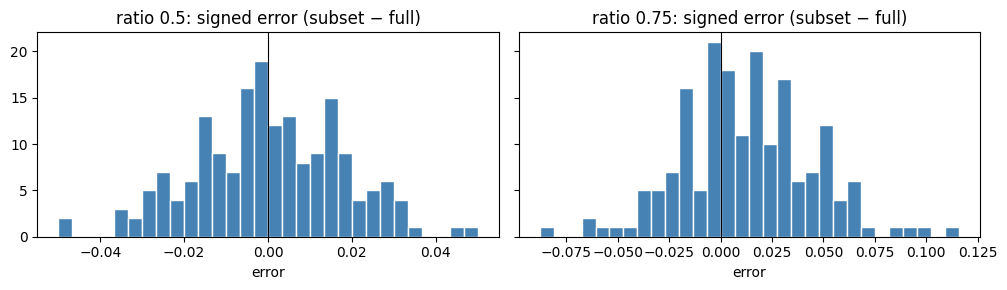

+0.1160  official__verified.20240721_amazon-q-developer-agent-20240719-dev
+0.1000  hosted_vllm__qwen3.5-35b-a3b.qwen3_5_35b_a3b
+0.0920  official__bash-only.20251211_mini-v1.17.2_gpt-5.2-2025-12-11-high
+0.0880  official__verified.20240615_appmap-navie_gpt4o
-0.0880  official__verified.20250110_learn_by_interact_claude3.5


In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
for ax, (tag, e) in zip(axes, evals.items()):
    errs = np.array(list(e["per_model_errors"].values()))
    ax.hist(errs, bins=30, color="steelblue", edgecolor="white")
    ax.axvline(0, color="k", lw=0.8)
    ax.set_title(f"ratio {e['ratio']}: signed error (subset − full)")
    ax.set_xlabel("error")
plt.tight_layout()
plt.show()

# Largest absolute errors at ratio 0.75
worst = sorted(evals["0p75"]["per_model_errors"].items(), key=lambda kv: -abs(kv[1]))[:5]
for m, err in worst:
    print(f"{err:+.4f}  {m}")